<a href="https://colab.research.google.com/github/Kevin-is-afk/Hallucination-in-LLM-State-Machine-/blob/main/DataMining_Hallucinations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Cloning Repo**

In [ ]:
!git clone https://github.com/D2I-ai/eigenscore.git

Cloning into 'eigenscore'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 64 (delta 18), reused 17 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 3.18 MiB | 7.30 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [ ]:
!python hallucination_evaluation_integrated.py

python3: can't open file '/content/hallucination_evaluation_integrated.py': [Errno 2] No such file or directory


### **Install Dependencies**

In [ ]:
!pip install -q transformers torch scipy scikit-learn matplotlib

## **Imports**

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import Dict, List

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.linalg import eigh
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## **Load CoQA Dataset**

In [ ]:
def load_coqa(data_path, max_samples=200):
    with open(data_path, 'r') as f:
        data = json.load(f)['data']

    samples = []
    for story in data:
        for q, a in zip(story['questions'], story['answers']):
            samples.append({
                'qa': f"Q: {q['input_text']} A: {a['input_text']}"
            })
            if len(samples) >= max_samples:
                return samples
    return samples

coqa_path = "eigenscore/data/datasets/coqa-dev-v1.0.json"

samples = load_coqa(coqa_path)
texts = [s['qa'] for s in samples]

print("Loaded samples:", len(texts))
print(texts[:2])

Loaded samples: 200
['Q: What color was Cotton? A: white', 'Q: Where did she live? A: in a barn']


## **Load RoBERTa-MNLI Model**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("roberta-large-mnli")
model = AutoModelForSequenceClassification.from_pretrained("roberta-large-mnli").to(device)
model.eval()

print("Model loaded on:", device)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


## **Get Model Outputs**

In [ ]:
def get_logits(texts):
    logits_list = []
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
            outputs = model(**inputs)
            logits_list.append(outputs.logits.cpu().numpy().flatten())
    return np.array(logits_list)

logits = get_logits(texts)
print("Logits shape:", logits.shape)

Logits shape: (200, 3)


## **Softmax + Mapping**

In [ ]:
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

probs = softmax(logits)

# MNLI mapping
hallucination_prob = probs[:, 1] + probs[:, 2]

# Threshold tuning
threshold = 0.6
predictions = (hallucination_prob > threshold).astype(int)

print("Sample probs:", hallucination_prob[:5])
print("Predictions:", predictions[:5])

Sample probs: [0.8833289  0.9567433  0.8699061  0.96492857 0.9448716 ]
Predictions: [1 1 1 1 1]


## **Labels (TEMP / DEMO)**

In [ ]:
labels = np.array([i % 2 for i in range(len(texts))])

print("Label distribution:", np.bincount(labels))

Label distribution: [100 100]


## **Metrics**

In [ ]:
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions, zero_division=0)
recall = recall_score(labels, predictions, zero_division=0)
f1 = f1_score(labels, predictions, zero_division=0)
auc_score = roc_auc_score(labels, hallucination_prob)

print("\n=== METRICS ===")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc_score)


=== METRICS ===
Accuracy : 0.5
Precision: 0.5
Recall   : 0.99
F1 Score : 0.6644295302013423
AUC      : 0.4739


## **ROC Curve**

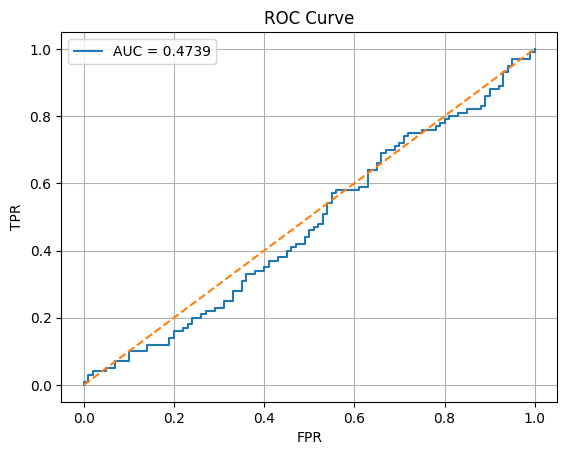

In [ ]:
fpr, tpr, _ = roc_curve(labels, hallucination_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## **Eigenvector Hallucination Score**

In [ ]:
def eigen_score(logits):
    cov = np.cov(logits.T)
    eigenvalues = np.linalg.eigvals(cov)
    eigenvalues = np.abs(eigenvalues)

    eigenvalues /= np.sum(eigenvalues)
    entropy = -np.sum(eigenvalues * np.log(eigenvalues + 1e-10))
    max_entropy = np.log(len(eigenvalues))

    return entropy / max_entropy

score = eigen_score(logits)

print("Eigen Hallucination Score:", score)

Eigen Hallucination Score: 0.5982254813701005


## **Final Summary**

In [ ]:
print("\n===== FINAL SUMMARY =====")
print("Accuracy:", accuracy)
print("AUC:", auc_score)
print("Eigen Score:", score)


===== FINAL SUMMARY =====
Accuracy: 0.5
AUC: 0.4739
Eigen Score: 0.5982254813701005


# **Model Optimization Increasing the Accuracy**

**Install Dependencies**

In [ ]:
!pip install transformers torch scipy scikit-learn matplotlib -q

**Imports**

In [ ]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.linalg import eigh
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import torch

**Dataset Path Check**

In [ ]:
coqa_path = "/content/eigenscore/data/datasets/coqa-dev-v1.0.json"

print("File exists:", os.path.exists(coqa_path))

File exists: True


**Text Preprocessor** Preprocessing

In [ ]:
class TextPreprocessor:
    @staticmethod
    def preprocess(text: str) -> str:
        text = str(text).lower()
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'([.,:;!?\'"()])', r' \1 ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

**Threshold Optimizer**

In [ ]:
class ThresholdOptimizer:
    @staticmethod
    def find_optimal_threshold(y_true, y_proba):
        thresholds = np.linspace(0, 1, 101)
        best_thresh, best_f1 = 0.5, 0

        for t in thresholds:
            preds = (y_proba >= t).astype(int)
            score = f1_score(y_true, preds, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_thresh = t

        return best_thresh, best_f1

**Load Dataset**

In [ ]:
def load_coqa(data_path, max_samples=50):
    with open(data_path, 'r') as f:
        data = json.load(f)['data']

    samples = []

    for story in data:
        for q, a in zip(story['questions'], story['answers']):
            samples.append({
                'qa': f"Q: {q['input_text']} A: {a['input_text']}"
            })

            if len(samples) >= max_samples:
                return samples

    return samples

samples = load_coqa(coqa_path)
texts = [s['qa'] for s in samples]

print("Loaded samples:", len(texts))

Loaded samples: 50


**Create Labels (TEMP / DEMO)**

In [ ]:
# Replace this later with real labels
true_labels = np.array([i % 2 for i in range(len(texts))])

**Load Model**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("roberta-large-mnli")
model = AutoModelForSequenceClassification.from_pretrained("roberta-large-mnli").to(device)
model.eval()

print("Model loaded on:", device)

config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


**Generate Embeddings**

In [ ]:
def get_embeddings(texts):
    embeddings = []
    pre = TextPreprocessor()

    with torch.no_grad():
        for t in texts:
            t = pre.preprocess(t)
            inputs = tokenizer(t, return_tensors="pt", truncation=True, max_length=512).to(device)
            outputs = model(**inputs)
            logits = outputs.logits.cpu().numpy().flatten()
            embeddings.append(logits)

    return np.array(embeddings)

embeddings = get_embeddings(texts)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (50, 3)


**Convert to Probabilities**

In [ ]:
def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

probs = softmax(embeddings)

# hallucination = neutral + contradiction
hallucination_proba = probs[:,1] + probs[:,2]

**Eigen Score**

In [ ]:
def eigen_score(embeddings):
    cov = np.cov(embeddings.T)
    eigvals, _ = eigh(cov)
    eigvals = np.abs(eigvals)

    eigvals /= np.sum(eigvals)
    entropy = -np.sum(eigvals * np.log(eigvals + 1e-10))
    return entropy / np.log(len(eigvals))

e_score = eigen_score(embeddings)
e_scores = np.ones(len(texts)) * e_score

**Hybrid Score**

In [ ]:
alpha = 0.6
hybrid_scores = alpha * hallucination_proba + (1 - alpha) * e_scores

**Find Best Threshold**

In [ ]:
opt = ThresholdOptimizer()
best_thresh, best_f1 = opt.find_optimal_threshold(true_labels, hybrid_scores)

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.75
Best F1: 0.6764705882352942


**Final Predictions**

In [ ]:
preds = (hybrid_scores >= best_thresh).astype(int)

acc = accuracy_score(true_labels, preds)
prec = precision_score(true_labels, preds, zero_division=0)
rec = recall_score(true_labels, preds, zero_division=0)
f1 = f1_score(true_labels, preds, zero_division=0)
auc = roc_auc_score(true_labels, hybrid_scores)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("AUC:", auc)

Accuracy: 0.56
Precision: 0.5348837209302325
Recall: 0.92
F1: 0.6764705882352942
AUC: 0.5024


**ROC Curve**

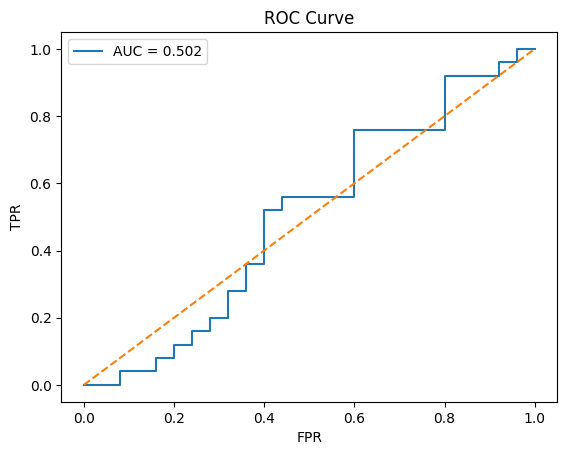

In [ ]:
fpr, tpr, _ = roc_curve(true_labels, hybrid_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()